# Phase 7 - Modern Transformer Families

> **Transformer Mastery - Phase Notebook**

## Objective
Understand how major Transformer families differ in architecture and objective: encoder-only BERT-style models, decoder-only GPT-style models, encoder-decoder T5-style models, LLaMA-style causal LMs, Vision Transformers, and the idea of multimodal Transformers.

### Notebook standard
- Reproducible setup
- Concepts → implementation → experiment → interpretation
- Explicit sanity checks
- Visual diagnostics
- Practical takeaways
- Limitations clearly stated

## 1. Setup

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')

SEED = 32
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

print("All imports successful.")



Using device: cpu
PyTorch version: 2.11.0+cpu
All imports successful.


## 2. Architecture Map

| Family | Typical objective | Main architecture | Common use |
|---|---|---|---|
| BERT | Masked-token prediction | Encoder-only | Representation / classification |
| GPT | Next-token prediction | Decoder-only | Generation |
| T5 | Text-to-text | Encoder-decoder | Transformation / generation |
| LLaMA-style | Next-token prediction | Decoder-only | General-purpose causal LM |
| ViT | Patch classification | Encoder-only | Vision |
| Multimodal Transformer | Joint/conditional modeling | Depends on system | Text + image/audio/video |

The key lesson is that **"Transformer" is an architecture family, not one single model design**.

## 3. One Attention Core, Different Masks

In [2]:
def attention(q, k, v, casual=False):
    d      = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d)
    if casual:
        T    = scores.size(-1)
        mask = torch.triu(
            torch.ones(T, T, device=scores.device, dtype=torch.bool), diagonal=1
        )
        scores = scores.masked_fill(mask, float("-inf"))
    weights = scores.softmax(dim=-1)
    return weights @ v, weights


In [3]:
T, D = 8, 32
q = torch.randn(1, T, D)
k = torch.randn(1, T, D)
v = torch.randn(1, T, D)

_, full_w   = attention(q, k, v, casual=False)
_, causal_w = attention(q, k, v, casual=True)


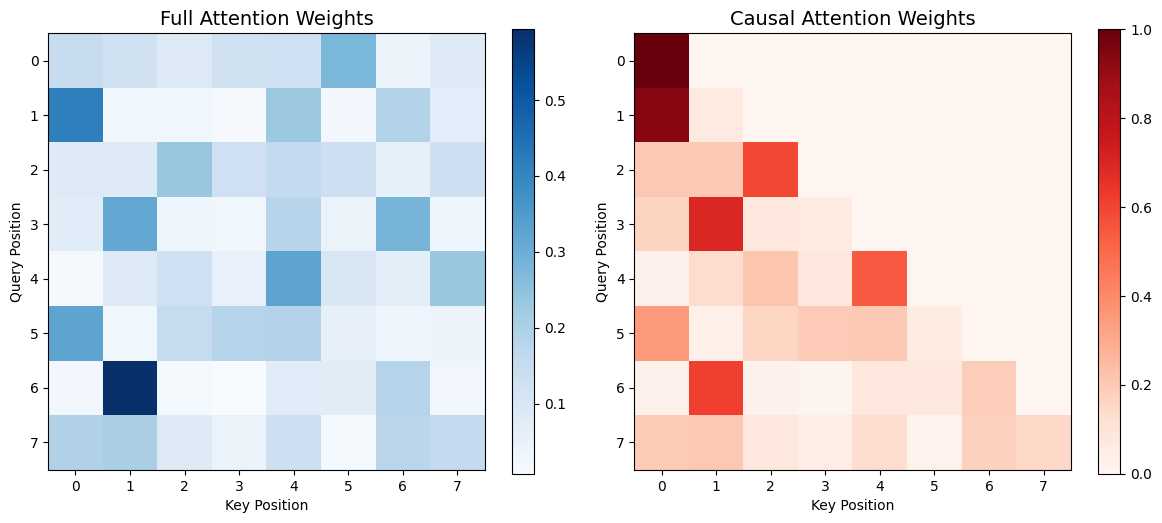

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(full_w[0].detach().numpy(), cmap="Blues")
axes[0].set_title("Full Attention Weights", fontsize=14)
axes[0].set_xlabel("Key Position"); axes[0].set_ylabel("Query Position")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(causal_w[0].detach().numpy(), cmap="Reds")
axes[1].set_title("Causal Attention Weights", fontsize=14)
axes[1].set_xlabel("Key Position"); axes[1].set_ylabel("Query Position")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## 4. BERT-Style Masked Language Modeling

In [5]:
sentence  = ["transformers", "learn", "relationships", "between", "tokens"]
MASK      = "<mask>"
masked    = sentence.copy()
masked[2] = MASK

print("Original sentence: ", " ".join(sentence))
print("Masked sentence  : ", " ".join(masked))

print("---")

print("Objective: Predict the masked token using the surrounding context.")


Original sentence:  transformers learn relationships between tokens
Masked sentence  :  transformers learn <mask> between tokens
---
Objective: Predict the masked token using the surrounding context.


## 5. GPT-Style Next-Token Prediction

In [6]:
sequence = ["transformers", "learn", "relationships", "between", "tokens"]
pairs = list(zip(sequence[:-1], sequence[1:]))

for context, target in pairs:
    print(f"context={context!r:15s} -> target={target!r}")

print("\nObjective: predict the next token using only previous context.")

context='transformers'  -> target='learn'
context='learn'         -> target='relationships'
context='relationships' -> target='between'
context='between'       -> target='tokens'

Objective: predict the next token using only previous context.


## 6. T5-Style Text-to-Text

In [7]:
examples = [
    ("Translate English to French: hello", "bonjour"),
    ("Summarize: transformers use attention", "attention-based models"),
    ("Classify: this movie is excellent", "positive"),
]
print("Examples of tasks that transformers can perform:")

for inp, target in examples:
    print(f"input={inp!r:40s} -> target={target!r}")
    print()

Examples of tasks that transformers can perform:
input='Translate English to French: hello'     -> target='bonjour'

input='Summarize: transformers use attention'  -> target='attention-based models'

input='Classify: this movie is excellent'      -> target='positive'



## 7. Vision Transformer: Image → Patches → Tokens

In [8]:
# A 32x32 RGB image divided into 8x8 patches creates 16 image tokens.
H = W    = 32
PATCH    = 8
CHANNELS = 3

num_patches = (H // PATCH) * (W // PATCH)
patch_dim   = PATCH * PATCH * CHANNELS

image = torch.randn(1, CHANNELS, H, W)

# unfold into non-overlapping patches
patches = image.unfold(2, PATCH, PATCH).unfold(3, PATCH, PATCH)
patches = patches.permute(0,2,3,1,4,5).contiguous()
patches = patches.view(1, num_patches, patch_dim)

print("Image shape :", tuple(image.shape))
print("Patch tokens:", tuple(patches.shape))
print("Each patch becomes one token vector.")

Image shape : (1, 3, 32, 32)
Patch tokens: (1, 16, 192)
Each patch becomes one token vector.


## 8. Family Comparison Experiment

In [9]:
families = ["BERT", "GPT", "T5", "LLaMA", "ViT"]
objective = [
    "masked token",
    "next token",
    "text-to-text",
    "next token",
    "image classification"
]
architecture = [
    "encoder",
    "decoder",
    "encoder-decoder",
    "decoder",
    "encoder"
]

for f, o, a in zip(families, objective, architecture):
    print(f"{f:8s} | {a:15s} | {o}")

BERT     | encoder         | masked token
GPT      | decoder         | next token
T5       | encoder-decoder | text-to-text
LLaMA    | decoder         | next token
ViT      | encoder         | image classification


## Phase 7 - What You Should Understand

Don't memorize model names as isolated facts.

The useful abstraction is:

**architecture + attention direction + training objective + modality + downstream use**

Once you understand that mapping, new Transformer variants become much easier to learn.